In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)
import numpy as np

In [9]:
file_path_s1 = '/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/s1_table.xlsx'
s1 = pd.read_excel(file_path_s1)

In [2]:
file_path_s2 = '/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/s2_table.csv' 
s2 = pd.read_csv(file_path_s2)

In [4]:
unique_bait_count = s2['Bait'].nunique()
print(unique_bait_count)

525


In [5]:
# Want to filter s2 table for RBPs that are in the glossary
# gloss = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/K562_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv', sep='\t')
gloss2 = pd.read_csv('/project/PlatigLab/users/reece/Yogi_Project/street_ppi_plots/HepG2_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv', sep='\t')

In [6]:
# Get the list of protein names from glossary
# gloss_protein_names = gloss.columns.tolist()
gloss2_protein_names = gloss2.columns.tolist()

# Filter s2 so it's only rows with Bait from glossary
filtered_s2 = s2[s2["Bait"].isin(gloss2_protein_names)]

In [8]:
# Also need to filter the prey column

# Filter s2 so it's only rows with Bait from glossary
more_filtered_s2 = filtered_s2[filtered_s2["Prey"].isin(gloss2_protein_names)]

In [10]:
final_s2 = more_filtered_s2[["Bait", "Prey", "Interaction_support", "IP_interaction_type", "PPI_support", "bait_eclipped", "prey_eclipped"]]

In [12]:
final_s2.to_csv("PPI_table_hepg2.csv", index = False)

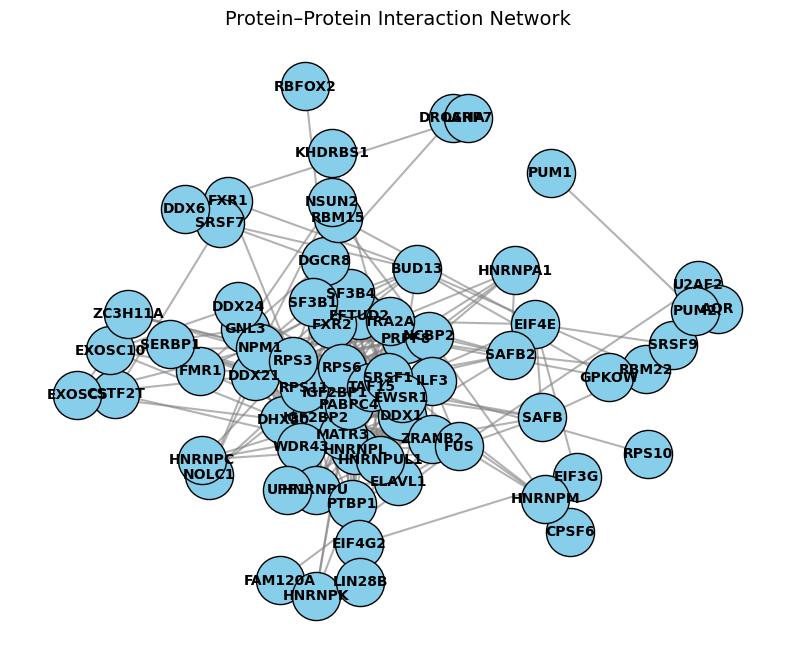

In [33]:
# Create a graph
G = nx.from_pandas_edgelist(final_s2, source="Bait", target="Prey")

# Draw the networ
# Choose a layout that spreads nodes apart
pos = nx.spring_layout(G, k=0.7, seed=42)  
# k controls spacing; increase k for more spread

plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=1200, edgecolors="black")

# Draw edges explicitly
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.6, edge_color="gray")

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

plt.title("Protein–Protein Interaction Network", fontsize=14)
plt.axis("off")
plt.show()
